# 3. Fourier Neural Operator

In this notebook, we demonstrate that it is possible to significantly improve upon the [baseline model](2-feature-based-regression.ipynb) by employing a physics-aligned approach: a multi-output Fourier Neural Operator (FNO) jointly predicts the neutron flux field $\phi(r)$ and the spatially-resolved macroscopic absorption cross-section $\Sigma_a(r)$. The homogenised cross-section $\Sigma_{homog}$ is then computed from these two predicted fields. [`PhysicsNeMo`](https://github.com/NVIDIA/physicsnemo) is used to train the FNO, abstracting away the underlying model architecture and simplifying the training process.

In [1]:
from torch.utils.data import random_split

from src.fno import PincellDataset
from src.utils import plot_input, plot_output, plot_comparison, compute_homogenized_xs

training = True

Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.


/home/mhobbs/miniconda3/envs/ai-for-science/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load dataset

Load the full dataset using the `PincellDataset` class, which reads the input data and corresponding outputs. The dataset is then split into training, validation and test sets using a 64/16/20 ratio. Adjust the metadata path as required.

In [2]:
full_dataset = PincellDataset(
    input_dir="data/input/npy",
    output_dir="data/output",
    resolution=500,
    tally_name="physics",
    metadata_path="data/metadata.csv"
)

n = len(full_dataset)
train_size = int(0.64 * n)
val_size = int(0.16 * n)
test_size = n - train_size - val_size

training_data, val_data, test_data = random_split(
    full_dataset, [train_size, val_size, test_size]
)

print(f"Train: {len(training_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

Train: 128, Val: 32, Test: 40


Inspect a single sample from the training set to verify the data shapes, types and values. Visualise the input geometry and the corresponding neutron flux field as a basic sanity check.

------------------------------
Enrichment:   2.155561923980713
------------------------------
Mask Shape:         torch.Size([500, 500])
Enrichment Shape:   torch.Size([])
Flux Shape:         torch.Size([500, 500])
Sigma_a Shape:      torch.Size([500, 500])
------------------------------
Mask Type:        torch.int64
Flux Type:        torch.float32
Sigma_a Type:     torch.float32


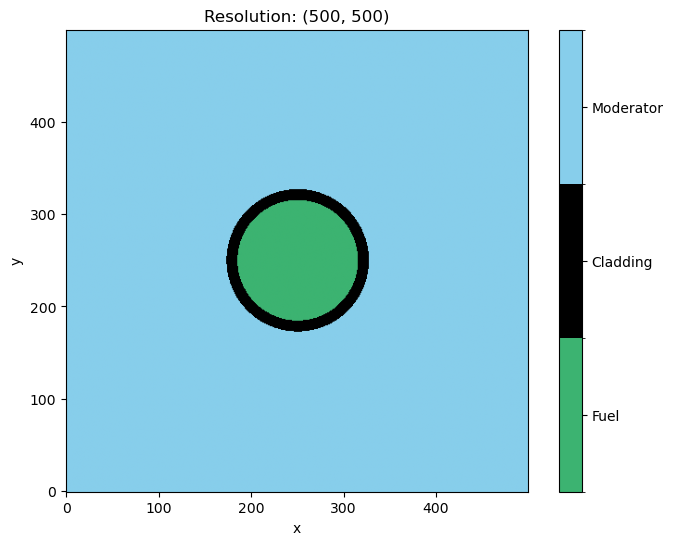

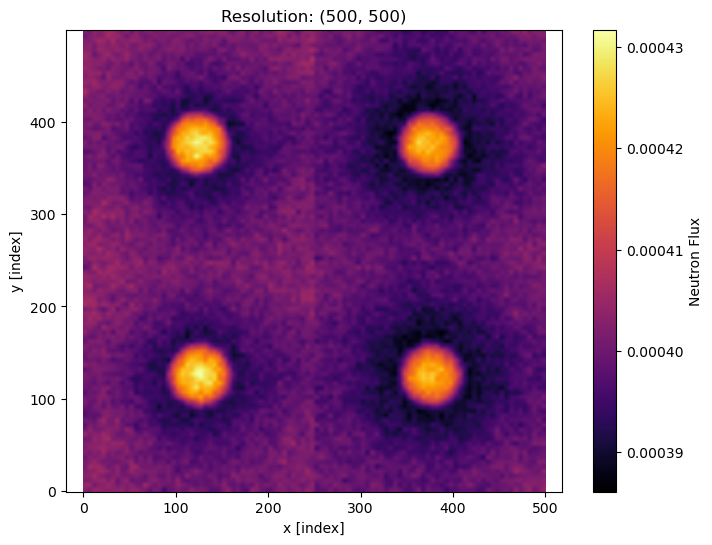

In [3]:
mask, enrichment, flux, sigma_a_map, xs = training_data[0]

print("-" * 30)
print(f"Enrichment:   {enrichment}")

print("-" * 30)
print(f"Mask Shape:         {mask.shape}")
print(f"Enrichment Shape:   {enrichment.shape}")
print(f"Flux Shape:         {flux.shape}")
print(f"Sigma_a Shape:      {sigma_a_map.shape}")
print("-" * 30)

print(f"Mask Type:        {mask.dtype}")
print(f"Flux Type:        {flux.dtype}")
print(f"Sigma_a Type:     {sigma_a_map.dtype}")

plot_input(mask)
plot_output(flux)

## Training

Define the training configuration using a frozen dataclass. This includes dataset parameters, training hyperparameters and the FNO model architecture settings. Users can adjust these values to experiment with different model configurations.

###  Define the configuration

In [1]:
from dataclasses import dataclass

@dataclass(frozen=True)
class Config:
    """
    Configuration
    """
    # Data paths
    input_dir: str = "data/input/npy"
    output_dir: str = "data/output"
    tally_name: str = "physics"
    
    # Dataset
    resolution: int = 500
    
    # Training
    batch_size: int = 10
    epochs: int = 50
    initial_lr: float = 1e-3
    num_workers: int = 4
    
    # Model
    in_channels: int = 4     # Fuel, Cladding, Moderator, Enrichment
    out_channels: int = 2    # Neutron flux field and absorption cross-section map
    dimension: int = 2
    decoder_layers: int = 2
    decoder_layer_size: int = 64
    latent_channels: int = 64
    num_fno_layers: int = 5
    num_fno_modes: int = 24

In [5]:
cfg = Config()

### Run the training process

The `Trainer` class abstracts the underlying [PhysicsNeMo FNO implementation](https://docs.nvidia.com/physicsnemo/25.11/physicsnemo/api/models/fnos.html), handling model instantiation, data loading, normalisation and the training loop. This allows users to train the FNO with minimal boilerplate - requiring only a configuration object and a dataset. In this instance, the `Trainer` class assumes that the model and dataset are small enough to fit on a single GPU; however, `PhysicsNeMo` makes it straightforward to implement both data and domain parallelism for larger problems.

In [6]:
from src.fno import Trainer

Computing statistics: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:03<00:00, 33.09it/s]


Log-space statistics:
  flux     — mean=-8.1154, std=0.1884
  sigma_a  — mean=-4.5086, std=1.1368
Starting training on cuda...


Training:  20%|████████████████████████                                                                                                | 10/50 [03:51<15:20, 23.02s/it]

Epoch [10/50] Train Loss: 0.045258 | Validation Loss: 0.066572


Training:  40%|████████████████████████████████████████████████                                                                        | 20/50 [07:43<11:35, 23.19s/it]

...

Epoch [30/50] Train Loss: 0.018478 | Validation Loss: 0.046247


Training:  80%|████████████████████████████████████████████████████████████████████████████████████████████████                        | 40/50 [15:27<03:52, 23.23s/it]

Epoch [40/50] Train Loss: 0.017351 | Validation Loss: 0.048939


Training: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [19:19<00:00, 23.19s/it]


Epoch [50/50] Train Loss: 0.013465 | Validation Loss: 0.049229
Checkpoint saved to fno_flux_model.pth


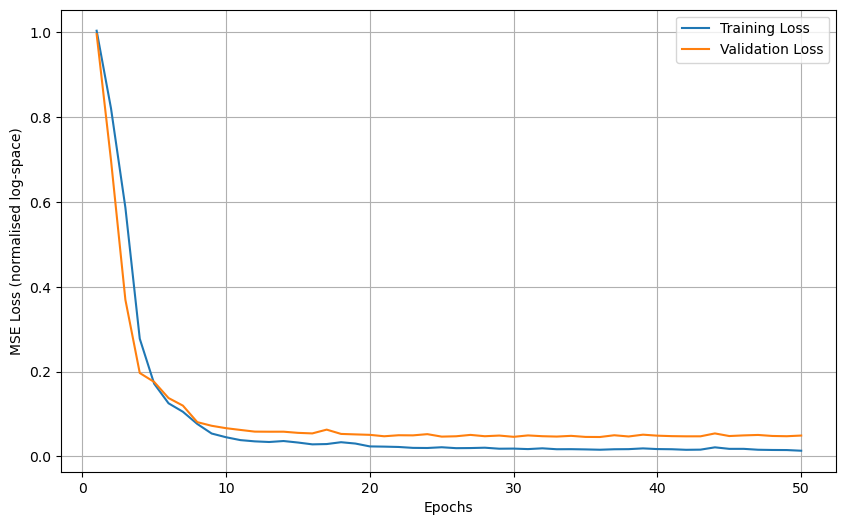

In [7]:
if training:
    trainer = Trainer(cfg, training_data, val_data)
    trainer.train()

## Inference

Load the trained FNO model via the `Inference` class and evaluate it on a sample from the held-out test set. The FNO predicts both the neutron flux field $\phi(r)$ and the absorption cross-section map $\Sigma_a(r)$, which are then used to compute the homogenised cross-section $\Sigma_{homog}$ via flux-weighted averaging. Although we homogenise the absorption cross-section here, the same approach applies to any reaction type, including fission $\Sigma_f$ and scattering $\Sigma_s$. We compare the observed and predicted flux distributions visually and report both the flux and cross-section values to assess predictive accuracy.

In [8]:
from src.fno import Inference
from src.utils import compute_homogenized_xs

In [9]:
inference = Inference(cfg)

Model loaded from fno_flux_model.pth
Normalisation stats (per channel): log_mean=[-8.115410804748535, -4.508639812469482], log_std=[0.18835192918777466, 1.136831521987915]


/home/mhobbs/Documents/dev/ai-for-science/src/fno.py:440: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=self.device)


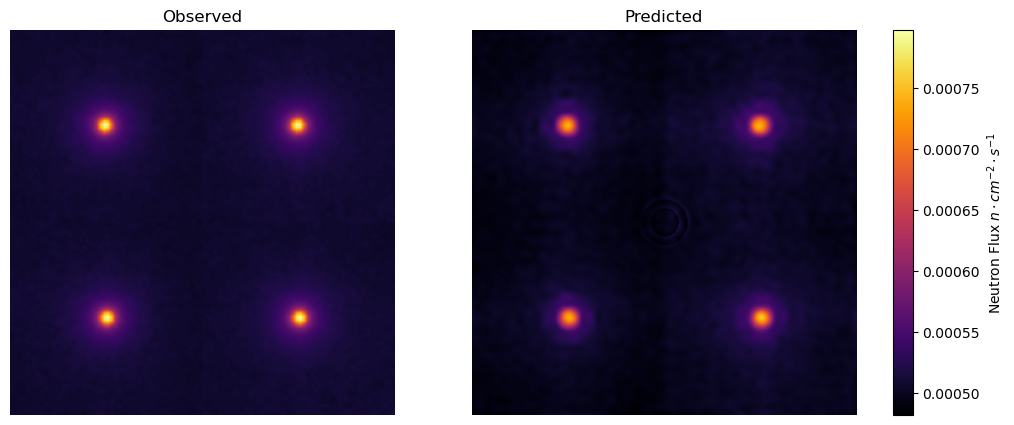

Enrichment: 3.50%
XS (observed): 1.4598e-02 | XS (predicted): 1.4885e-02
Flux (observed): 1.2857e+02 | Flux (predicted): 1.2611e+02


In [17]:
mask, enrichment, flux, sigma_a_map, xs = test_data[2]
flux_pred, sigma_a_pred = inference.predict(mask, enrichment)
xs_pred = compute_homogenized_xs(sigma_a_pred, flux_pred)

plot_comparison(flux, flux_pred)
print(
    f"Enrichment: {enrichment:.2f}%\n"
    f"XS (observed): {xs:.4e} | XS (predicted): {xs_pred:.4e}\n"
    f"Flux (observed): {flux.sum():.4e} | Flux (predicted): {flux_pred.sum():.4e}"
)

## Testing

Evaluate the multi-output FNO on the held-out test set. The model predicts both the flux field and the absorption cross-section map; we report the relative L2 error for each channel and visualise a single sample.

In [11]:
metrics = inference.evaluate(test_data)
print(f"Flux Mean Relative Error: {metrics['flux_mean_rel_error']:.4f}")
print(f"Sigma_a Mean Relative Error: {metrics['sigma_a_mean_rel_error']:.4f}")

inference.plot_comparison(test_data, idx=0, save_path="comparison.png")

Evaluating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:04<00:00,  8.83it/s]


Flux Mean Relative Error: 0.0238
Sigma_a Mean Relative Error: 0.1501
Saved comparison plot to comparison.png


### True homogenised cross-section $\Sigma_{homog}$ vs predicted

Evaluate the trained FNO across the full test set by computing the predicted homogenised cross-section $\Sigma_{homog}$ for each sample and comparing it against the true value derived from simulation. Both the neutron flux $\phi(r)$ and the absorption cross-section $\Sigma_a(r)$ used in the homogenisation formula are predicted by the multi-output FNO.

We report the mean relative error and the coefficient of determination ($R^2$) as summary metrics, and plot the observed against predicted values. Points lying close to the dashed $x = y$ line indicate good predictive accuracy.

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

In [13]:
def get_true_and_predicted_xs(test_data):
    xs_true_list = []
    xs_pred_list = []

    for sample in test_data:
        mask, enrichment, flux, sigma_a_map, xs = sample
        flux_pred, sigma_a_pred = inference.predict(mask, enrichment)
        xs_pred = compute_homogenized_xs(sigma_a_pred, flux_pred)

        xs_true_list.append(xs)
        xs_pred_list.append(xs_pred)

    return np.array(xs_true_list), np.array(xs_pred_list)

mean_rel_error: 1.99764
r2: 0.97346


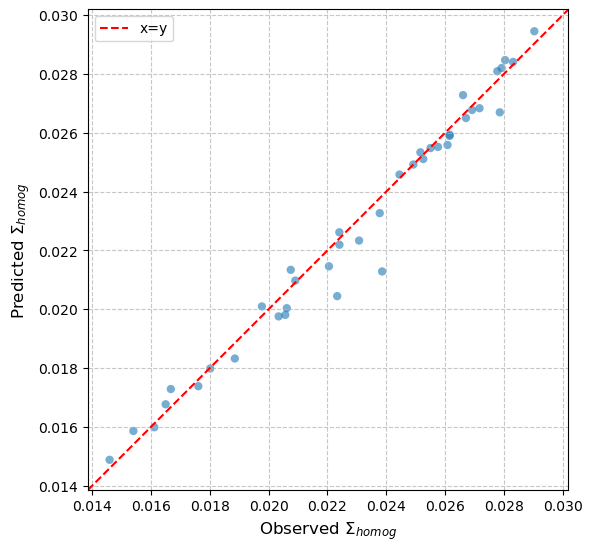

In [14]:
xs_true, xs_pred = get_true_and_predicted_xs(test_data)

rel_error = np.abs(xs_pred - xs_true) / xs_true * 100
mean_rel_error = rel_error.mean()

r2 = r2_score(xs_true, xs_pred)
print(f"mean_rel_error: {mean_rel_error:.5f}")
print(f"r2: {r2:.5f}")

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(xs_true, xs_pred, alpha=0.6, edgecolors='none')

lims = [min(xs_true.min(), xs_pred.min()), max(xs_true.max(), xs_pred.max())]
margin = (lims[1] - lims[0]) * 0.05
lims = [lims[0] - margin, lims[1] + margin]
ax.plot(lims, lims, 'r--', lw=1.5, label='x=y')

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Observed $\Sigma_{homog}$', fontsize=12)
ax.set_ylabel(r'Predicted $\Sigma_{homog}$', fontsize=12)
ax.legend()
ax.set_aspect('equal')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('observed-vs-predicted-fno.png', dpi=150)